
# On the Wave equation
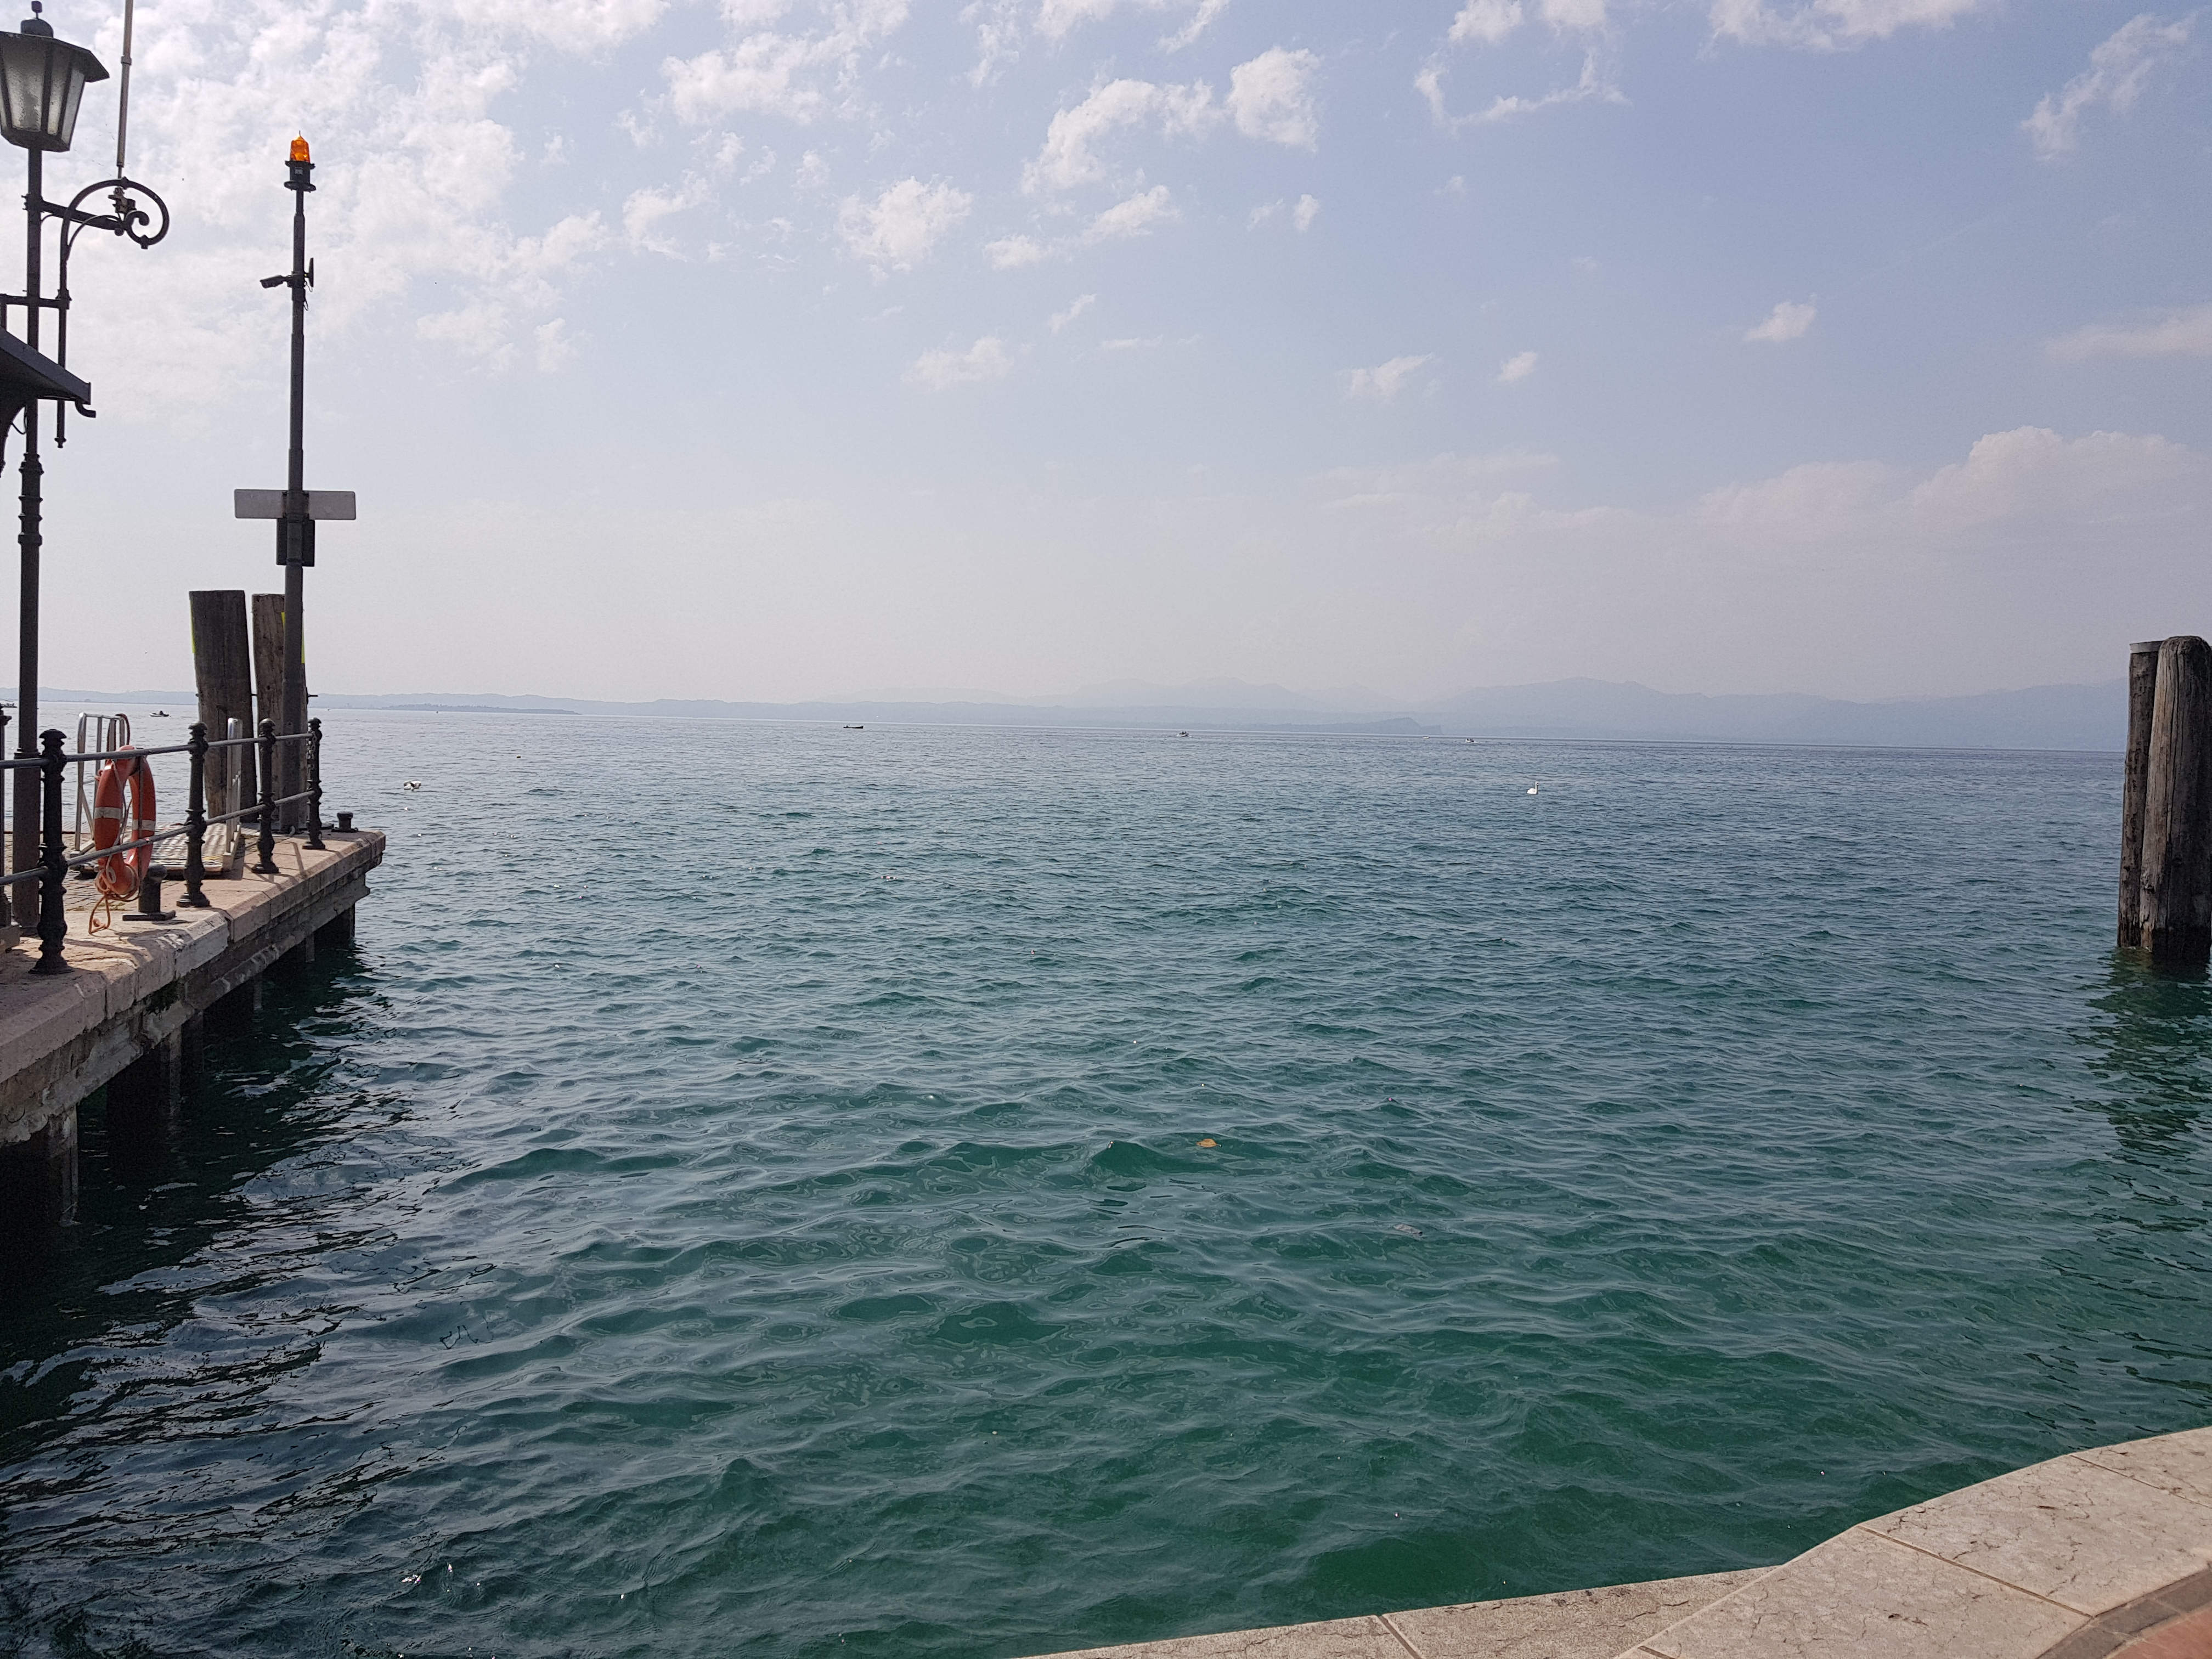
##### Photo from Peschiera del Garda, at Garda's lake

## Analytic and numerical treatments
### Amedeo Maria Favitta, 18 January 2021







We consider a scalar field $u$ which satisfies the wave equation:

$$ \frac{1}{c^2}\frac{\partial^2{u(x,t)}}{\partial{t^2}}-\Delta u(\vec{x},t)=0 $$

In particular, we focus on the 1+1-dimensional version:



$$ \frac{1}{c^2}\frac{\partial^2{u(x,t)}}{\partial{t^2}}-\frac{\partial^2{u(x,t)}}{\partial{x^2}}=0 $$


The wave equation is a hyperbolic partial differential equation and is very important in Physics, since it describes a lot of significant natural phenomena, such as the sound and electromagnetic waves.

As any partial differential equation (PDE), we need boundary and initial conditions. We will treat the following Boundary-Value problem:

 

$$ \begin{cases} 
\frac{1}{c^2}\frac{\partial^2{u(x,t)}}{\partial{t^2}}-\frac{\partial^2{u(x,t)}}{\partial{x^2}}=0 \ \ \ \ \ \ \ \ \ \ \ \ \ \ \  x \in [0,L] \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ t \in [0,T[  \\
u(x=0,t)=0 \\
u(x=L,t)=0 \\
\partial_t u(x,t=0)=0 \\
u(x,t=0)=f(x) \\
 \end{cases} $$


Such a problem describes the dynamical evolution of waves in a spatial domain with a limited extent, where Dirichlet boundary conditions are imposed at the two extremal points of the domain. This can, e.g., describe the sound waves of a violin or a guitar chord.

# Analytical solution

We take the ansatz u(x,t)=T(t)X(x) and substitute in the Wave PDE:
$$ \frac{\ddot{T}}{T}=-c^2 k^2 \\
   \frac{X''}{X}=-k^2 $$
   where $k$ needs to be a real constant.

If we impose the boundary and initial conditions above, we obtain:

$
T(t)= C \cos(k_nct), \\ 
X(x)= B \sin(k_nx), \\
$

where the modes 
$ k_n=\frac{ \pi n}{L}$ are quantized with
$n=1,2,...$ is a positive integer.

We then obtain as a result:

$
u(x,t)=T(t)X(x)=A \cos(k_nct) \sin(k_nx)=\frac{A}{2} [sin(k_n(ct-x))+sin(k_n(ct+x))]
$

A general solution of the BVP is given by a superposition of such separated-variable solutions:

   $ u(x,t)=\sum_{n=1}^{\infty} A_n \cos(k_nct) \sin(k_nx) \\
    u(x,t=0)=\sum_{n=1}^{\infty} A_n \sin(k_nx) \\
    f(x)=\sum_{n=1}^{\infty} f_n \sin(k_nx) dx \\
    $

with $f_n=\frac{2}{L} \int_{0}^{L} \sin(k_nx) f(x) dx $

 Consequently \
$ \\ u(x,t)=\sum_{n=1}^{\infty} f_n \cos(k_nct) \sin(k_nx) \\ $
 
 
 
    

And if $f(x)=\sin(k_nx) \\ $ we then obtain: \
$ u(x,t)=\sin(k_nx) \cos(k_nct) $

# Numerical resolution 


# CTCS numerical scheme

Consider as a discretized domain of the function $u(x,t)$ a space–time grid as shown in the figure. The problem is discretized by passing from $u(x,t)$ to $ u_{j}^{n}. $ 
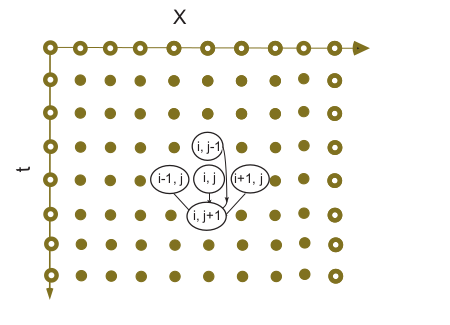
###### Fig.1 Illustration of the numerical scheme from Ref.[2]

The second-order time partial derivative is approximated using a CT finite difference:

$$ \frac{\partial^2 u(x,t)}{\partial t^2}  \rightarrow \frac{u_{j}^{n+1}+u_{j}^{n-1}-2u_{j}^{n} }{\Delta t^2} $$

Analogously for the spatial one:

$$ \frac{\partial^2 u(x,t)}{\partial x^2}  \rightarrow \frac{u_{j+1}^{n}+u_{j-1}^{n}-2u_{j}^{n} }{\Delta x^2} $$

$$ \frac{1}{c^2} \frac{u_{j}^{n+1}+u_{j}^{n-1}-2u_{j}^{n} }{\Delta t^2}- \frac{u_{j+1}^{n}+u_{j-1}^{n}-2u_{j}^{n} }{\Delta x^2} =0 $$

We then obtain the following scheme

$$ u_{j}^{n+1}=-u_{j}^{n-1}+2u_{j}^{n}+r^2(u_{j+1}^{n}+u_{j-1}^{n}-2u_{j}^{n})  $$

where $$ r= \frac{c \Delta t}{\Delta x} $$

# Numerical stability of the scheme

A Von Neumann analysis is carried out to verify under which conditions the scheme is stable.

  
We take $ u_{j}^{n}=A_0 \zeta ^n e^{i k j \Delta x} $ and substitute in the scheme:

$ \zeta^{n+1} e^{i k j \Delta x}=2\zeta^n e^{i k j \Delta x}-\zeta^{n-1} e^{i k j \Delta x}+r^2(\zeta^{n} e^{i k (j+1) \Delta x}+\zeta^{n} e^{i k (j-1) \Delta x}-2\zeta^{n} e^{i kj \Delta x}),$

Then, we obtain the following equation

$ \zeta^2-2[1-2r^2 \sin(\frac{k \Delta x}{2})]\zeta+1 =0 ,$

whose solutions are 

 $\zeta=[1-2r^2 \sin(\frac{k \Delta x}{2})]\pm \sqrt{[1-2r^2 \sin(\frac{k \Delta x}{2})]^2-1}  $

We have stability when  $ |\zeta|^2 \leq 1 $ and this happens for $ r \leq 1 $. 

 We display in the following some numerical animations showing the dynamical evolution of the waves with different initial conditions.

## Initial condition: One normal mode

In [16]:
from IPython.display import Video
Video("sin.mp4")

## Initial condition: Dirac delta at the center of the domain

In [17]:
Video("delta.mp4")

## Initial condition: Superposition of two normal modes leading to beats

In [15]:

Video("batti.mp4")

## $L^{\infty}$ error between the exact and numerical solutions

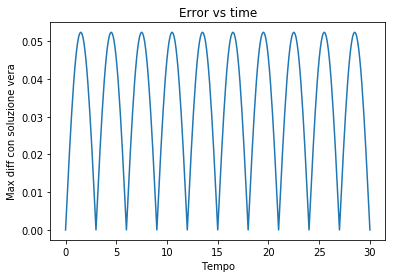

# Energy conservation

We can demostrate the existence of a constant of motion with the above Boundary-value problem, as follows.

We take the Wave equation, multiply it by $ \partial_{t} u $ and integrate over the interval $[a,b]$:
$$ \int_a^b \frac{1}{c^2}u_{tt}u_{t} dx - \int_a^b  u_{xx} u_{t} dx =0 $$
Integrate by parts the second integral and use Dirichlet's Boundary conditions:
$$ \int_a^b \frac{1}{c^2}u_{tt}u_{t} dx + \int_a^b  u_{x} u_{xt} dx =0 $$
Consequently
$$ \frac{dE}{dt}=0 $$ where $$ E=\frac{1}{2} \Biggl[ \int_a^b (u_{t})^2 dx + \int_a^b  c^2 (u_{x})^2 dx \Biggr] $$

This procedure is analogous to the one for obtaining a discretised energy compatible with the numerical scheme we have adopted. Take the discretised version of the Wave equation

$$ \frac{1}{c^2} \frac{u_{j}^{n+1}+u_{j}^{n-1}-2u_{j}^{n} }{\Delta t^2}- \frac{u_{j+1}^{n}+u_{j-1}^{n}-2u_{j}^{n} }{\Delta x^2} =0 $$

Multiply both sides by the central difference time first-derivative:
$$ \frac{(u_j^{n+1}-u_j^{n-1})}{2 \Delta t} $$

 

If we sum from $j=0$ to $j=N-2$ and multiply by $ \Delta x $, we obtain :
$$ \frac{E_h^{n+1/2}-E_h^{n-1/2}}{\Delta t} = 0, $$ \
where 
$$ E_{n+1/2}= \frac{1}{2} \Delta x \sum_j \Biggl[\biggl(\frac{u_{j}^{n+1}-u_{j}^{n} }{\Delta t}\biggr)^2+ \biggl(\frac{u_{j+1}^{n}-u_{j}^{n} }{\Delta x}\biggr)\biggl(\frac{u_{j+1}^{n+1}-u_{j}^{n+1} }{\Delta x}\biggr)  \Biggr].   $$





We show a plot of this numerical energy, which is trivially conserved by the numerical scheme. It is however useful to check our code is OK. 

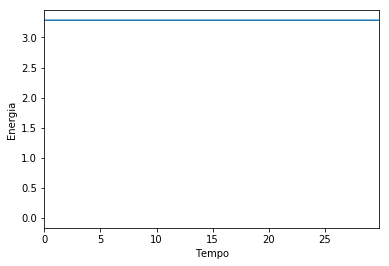

# Numerical dispersion and diffusion

We come back to the discretised wave equation

 $$ \frac{1}{c^2} \frac{u_{j}^{n+1}+u_{j}^{n-1}-2u_{j}^{n} }{\Delta t^2}- \frac{u_{j+1}^{n}+u_{j-1}^{n}-2u_{j}^{n} }{\Delta x^2} =0. $$
 
 We substitute the following Taylor series, evaluated  at the grid point (j,n):
 
 $$ u_{j}^{n+1}=u_{j}^{n}+dt \biggl(\frac{\partial u}{\partial t} \biggr)_{j}^n + \frac{dt^2}{2} \biggl(\frac{\partial^2 u}{\partial^2 t} \biggr)_{j}^n+...   $$
 \
 $$ u_{j}^{n-1}=u_{j}^{n}-dt \biggl(\frac{\partial u}{\partial t} \biggr)_{j}^n + \frac{dt^2}{2} \biggl(\frac{\partial^2 u}{\partial^2 t} \biggr)_{j}^n+...   $$
 \
 $$ u_{j+1}^{n}=u_{j}^{n}+dx \biggl(\frac{\partial u}{\partial x} \biggr)_{j}^n + \frac{dx^2}{2} \biggl(\frac{\partial^2 u}{\partial^2 x} \biggr)_{j}^n+...   $$
 \
 $$ u_{j-1}^{n}=u_{j}^{n}-dx \biggl(\frac{\partial u}{\partial x} \biggr)_{j}^n + \frac{dx^2}{2} \biggl(\frac{\partial^2 u}{\partial^2 x} \biggr)_{j}^n+...   $$
 We then obtain the following differential equation
 
 $$ \frac{1}{c^2} \biggl(\frac{\partial^2 u}{\partial^2 t} \biggr)_{j}^n - \biggl(\frac{\partial^2 u}{\partial^2 x} \biggr)_{j}^n = \frac{(-c^{2} dt^{2} + dx^{2})}{12} \biggl(\frac{\partial^{4} u}{\partial x^4} \biggr)_{j}^n+...  $$

If we perform a Fourier transform on this equation, it is easy to understand that we do not obtain a linear dispersion for the plane waves $ e^{i(\omega t - kx)} $. This clearly implies differences between phase and group velocities.
 

Substitute 
$ u_j^n = e^{-i({\omega }t_n-\kappa x_j)} $
in the discretised wave equation. \
If we follow the former calculations to evaluate stability conditions we obtain:

$ \begin{aligned} \sin \left( \frac{{\omega }\Delta t}{2}\right) = \pm r\sin \left( \frac{\kappa \Delta x}{2}\right) , \end{aligned} $

We can also calculate the phase and group velocities

\begin{aligned} {c}_{num}^{ph} =\frac{\omega}{k}=  \frac{c}{r\pi H}\sin ^{-1}\left( r\sin \left( \pi H\right) \right) , \quad {c}_{num}^{gr} =\frac{d \omega}{dk}= \frac{c \cos (\pi H)}{\cos \left( \sin ^{-1}\left( r\sin (\pi H)\right) \right) }, \end{aligned}

where
$ H=\frac{\kappa \Delta x}{2\pi } $.

We observe that we have $ c_{num}^{ph}=c_{num}^{gr}=c $, when $ H \leq 1/2 $ and $r=1$.

In the following, we show our pratical analyses of the evolution of such numerical errors.

# Plot $L^{\infty}$ error vs time 
## Data: dt=0.05, dx=0.1, $L^{\infty}$ error, calculated with respect to the solution of the PDE with higher-order derivatives
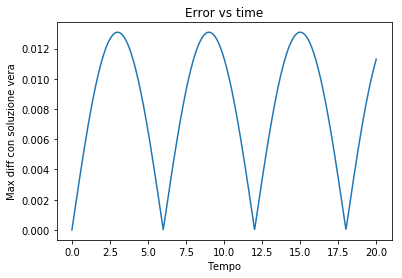

# Plot $L^{\infty}$ error vs time 
## Data: dt=0.05, dx=0.1, $L^{\infty}$ error calculated with respect to the analytical solution of the Wave PDE 
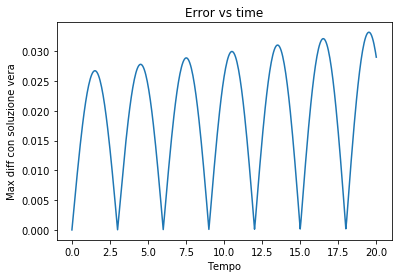

# Plot $L^{\infty} $error vs time 
## Dati: dt=0.1, dx=0.1, $L^{\infty}$ error per both the two cases
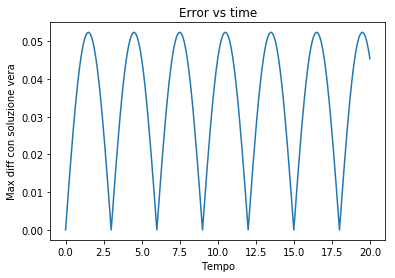

It is pretty clear from these plots that the choice $dx=cdt$ is the more convenient one, as it yields a numerical solution that is not a solution of another PDE, and there is no difference in the two cases about the $L^{\infty}$ error.

### Bibliography

1. R. Fiorentini, R. Ricci,  
   *Fondamenti di fisica computazionale*, Zanichelli, Bologna.

2. R. H. Landau, M. J. Páez, C. C. Bordeianu,  
   *Computational Physics: Problem Solving with Python*, Wiley-VCH.

3. G. Seriani, S. P. Oliveira (2020),  
   *Numerical modeling of mechanical wave propagation*, Rivista del Nuovo Cimento, **43**, 459–514. https://doi.org/10.1007/s40766-020-00009-0

 
